In [ ]:
import pandas as pd

df = pd.read_csv("diabetes_prediction_dataset.csv")
df.head(10)

# Count positives (1) and negative (0)

case_counts = df["diabetes"].value_counts()
print(case_counts)

diabetes
0    91500
1     8500
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Features = everything except diabetes column
X = df.drop("diabetes", axis=1)

# Target = diabetes column
y = df["diabetes"]

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])



Training set size: 80000
Testing set size: 20000


# **Which classification model can we use and why?**



Common models we can use:

	•	Logistic Regression → simple, interpretable, often works well for medical data.
	•	Decision Tree / Random Forest → good for handling mixed data and non-linear patterns.
	•	Support Vector Machine (SVM) → powerful for classification, especially with clear separation between classes.
	•	K-Nearest Neighbors (KNN) → simple, uses distance to classify new points.

The first go-to model for problems like this is Logistic Regression because:

	•	It directly handles binary outcomes (0/1).
	•	It’s interpretable (we can see how each feature contributes).
	•	It’s a baseline model to compare with others.


# ** Do we need to standardize the data?**

Yes. We do — because some features have very different scales.

Example from the dataset:

	•	Age might range from 20 → 80.
	•	Glucose could go 50 → 200.
	•	BMI might be around 18 → 40.

If we don’t standardize:

	•	Features with large numbers (like glucose) will dominate the model, making it unfair.
	•	Models like Logistic Regression, SVM, and KNN need data on the same scale.
	•	Decision trees don’t care about scaling, but since we’re starting with Logistic Regression → scaling is required.


In [ ]:
# Import encoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Find categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns

# Apply One-Hot Encoding to categorical columns, scale numeric ones
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), X.select_dtypes(exclude=["object"]).columns),
        ("cat", OneHotEncoder(drop="first"), categorical_cols)
    ]
)

# 4. Fit + transform training, only transform test
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1) Create the model
logreg = LogisticRegression(max_iter=1000, random_state=42)

# 2) Train (fit) the model on training data
logreg.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


Accuracy: 0.96045


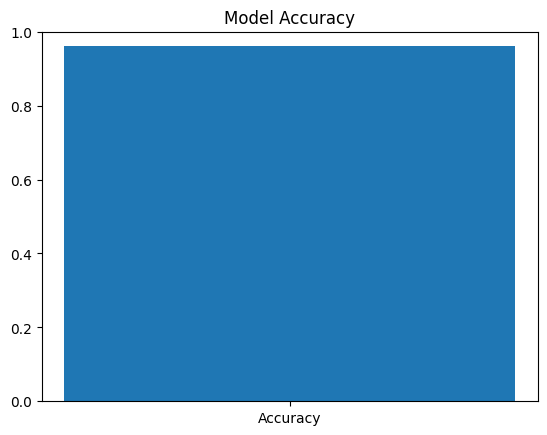

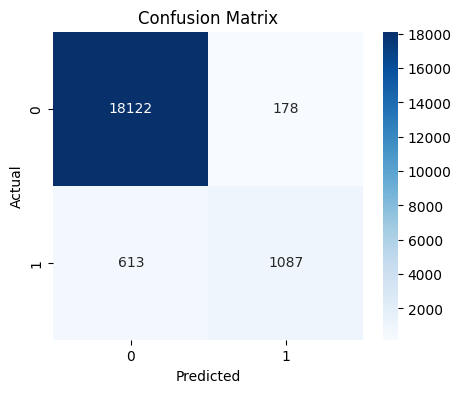


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Predict on the test set
y_pred = logreg.predict(X_test_scaled)

# 2) Accuracy Score
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Plot accuracy (bar plot)
plt.bar(["Accuracy"], [acc])
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.show()

# 3) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 4) Recall, Precision, F1-Score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

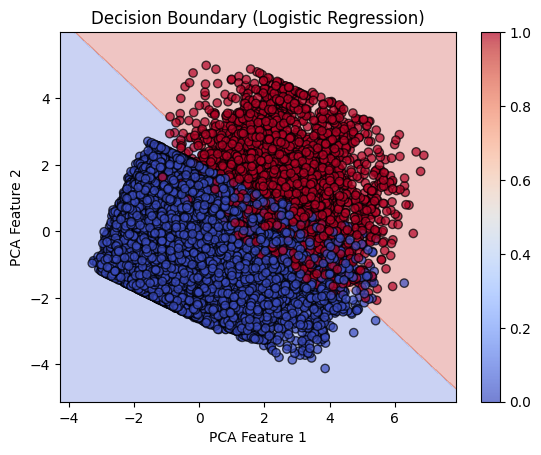

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Step 1: Reduce features to 2D for visualization
# (since the dataset has many columns, we use PCA to project to 2 dimensions)
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)

# Retrain logistic regression on the 2D features
from sklearn.linear_model import LogisticRegression
model_2d = LogisticRegression()
model_2d.fit(X_train_2d, y_train)

# Step 2: Create a mesh grid over the 2D space
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict for each point in the grid
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Step 3: Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Plot training points
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolor="k", cmap=plt.cm.coolwarm, alpha=0.7)

plt.title("Decision Boundary (Logistic Regression)")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.colorbar()
plt.show()

AUC Score: 0.9624980874316941


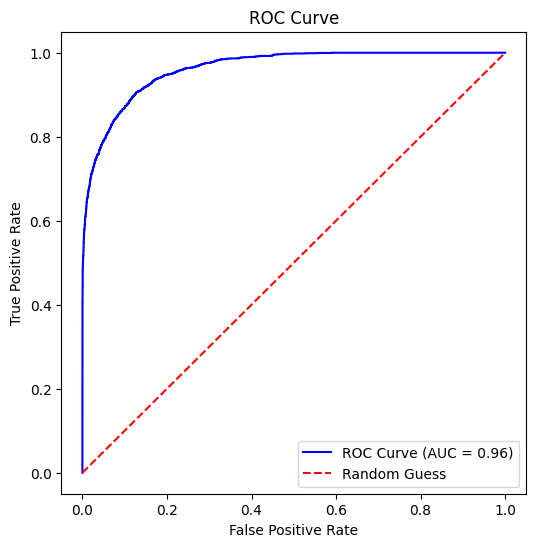

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (diabetes = 1)
y_probs = logreg.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Compute AUC
auc_score = roc_auc_score(y_test, y_probs)
print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], color='red', linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()